In [1]:
!pip install kagglehub

import kagglehub

# Download latest version
path = kagglehub.dataset_download("asaniczka/uk-optimal-product-price-prediction")

print("Path to dataset files:", path)

c:\Users\llam_\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\llam_\.cache\kagglehub\datasets\asaniczka\uk-optimal-product-price-prediction\versions\3


In [2]:
import pandas as pd
import os

path = r"C:\Users\llam_\.cache\kagglehub\datasets\asaniczka\uk-optimal-product-price-prediction\versions\3"

files = [f for f in os.listdir(path) if f.endswith('.csv')]
file_path = os.path.join(path, files[0])

df = pd.read_csv(file_path)

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
1. **Crosstab Analysis**:
    - Create a crosstab between the product `category` and the `isBestSeller` status.
    
    - Are there categories where being a best-seller is more prevalent? 
    	
    	*Hint: one option is to calculate the proportion of best-sellers for each category and then sort the categories based on this proportion in descending order.*

In [4]:
df.head()


,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [5]:
ct = pd.crosstab(df['category'], df['isBestSeller'])

ct_prop = ct.div(ct.sum(1), axis=0)

ct_prop_asc = ct_prop.sort_values(by=True, ascending=False)
print(ct)

print(ct_prop_asc)

isBestSeller                    False  True 
category                                    
3D Printers                       247      1
3D Printing & Scanning           4065      2
Abrasive & Finishing Products     245      5
Action Cameras                   1696      1
Adapters                          251      3
...                               ...    ...
Wind Instruments                  243      7
Window Treatments                 234      5
Women                           17559    213
Women's Sports & Outdoor Shoes   1939     20
eBook Readers & Accessories       246      0

[296 rows x 2 columns]
isBestSeller                       False     True 
category                                          
Grocery                         0.941865  0.058135
Smart Home Security & Lighting  0.942308  0.057692
Health & Personal Care          0.942314  0.057686
Mobile Phone Accessories        0.957529  0.042471
Power & Hand Tools              0.964661  0.035339
...                               

C:\Users\llam_\AppData\Local\Temp\ipykernel_111264\4197200613.py:3: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  ct_prop = ct.div(ct.sum(1), axis=0)


In [ ]:
#in groceries, smart home sec and health &personal care, best sellers are more prevalents.

In [6]:
2. **Statistical Tests**:
    - Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category.
    - Compute Cramér's V to understand the strength of association between best-seller status and category.

SyntaxError: unterminated string literal (detected at line 3) (393827673.py, line 3)

In [9]:
pip install scipy

  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl (37.3 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
from scipy.stats import chi2_contingency

In [11]:
chi2, p, dof, expect = chi2_contingency(ct)

print(f"P-valor: {p}")

P-valor: 0.0


In [12]:
import numpy as np

n = ct.sum().sum()

v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

print(f"Cramers: {v}")

Cramers: 0.1222829439760564


<Axes: ylabel='category'>

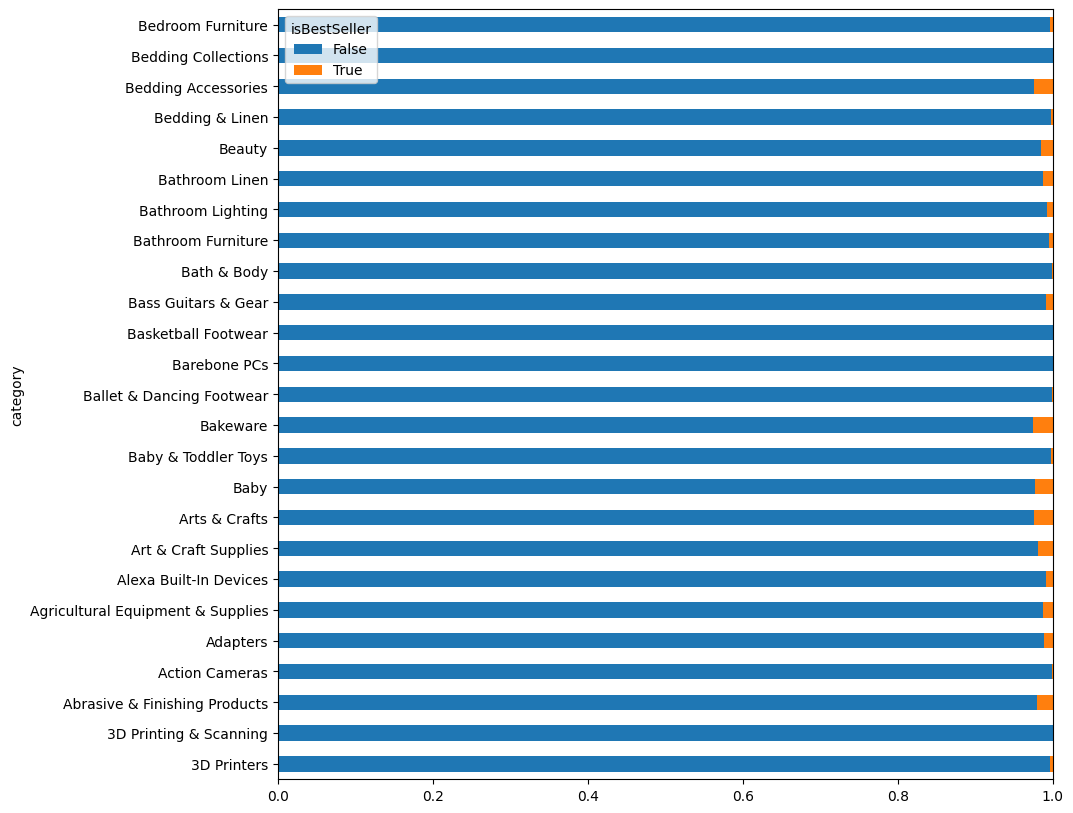

In [13]:
ct_prop.head(25).plot(kind="barh", stacked=True, figsize=(10,10))

In [14]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

print(f"Límite superior de precio: {upper_bound:.2f}")
print(f"Productos eliminados: {len(df) - len(df_clean)}")

Límite superior de precio: 99.99
Productos eliminados: 327688


In [15]:
top_20_categories = df_clean['category'].value_counts().head(20).index
df_top20 = df_clean[df_clean['category'].isin(top_20_categories)]


C:\Users\llam_\AppData\Local\Temp\ipykernel_111264\1008640509.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_top20, x='price', y='category', palette="coolwarm")


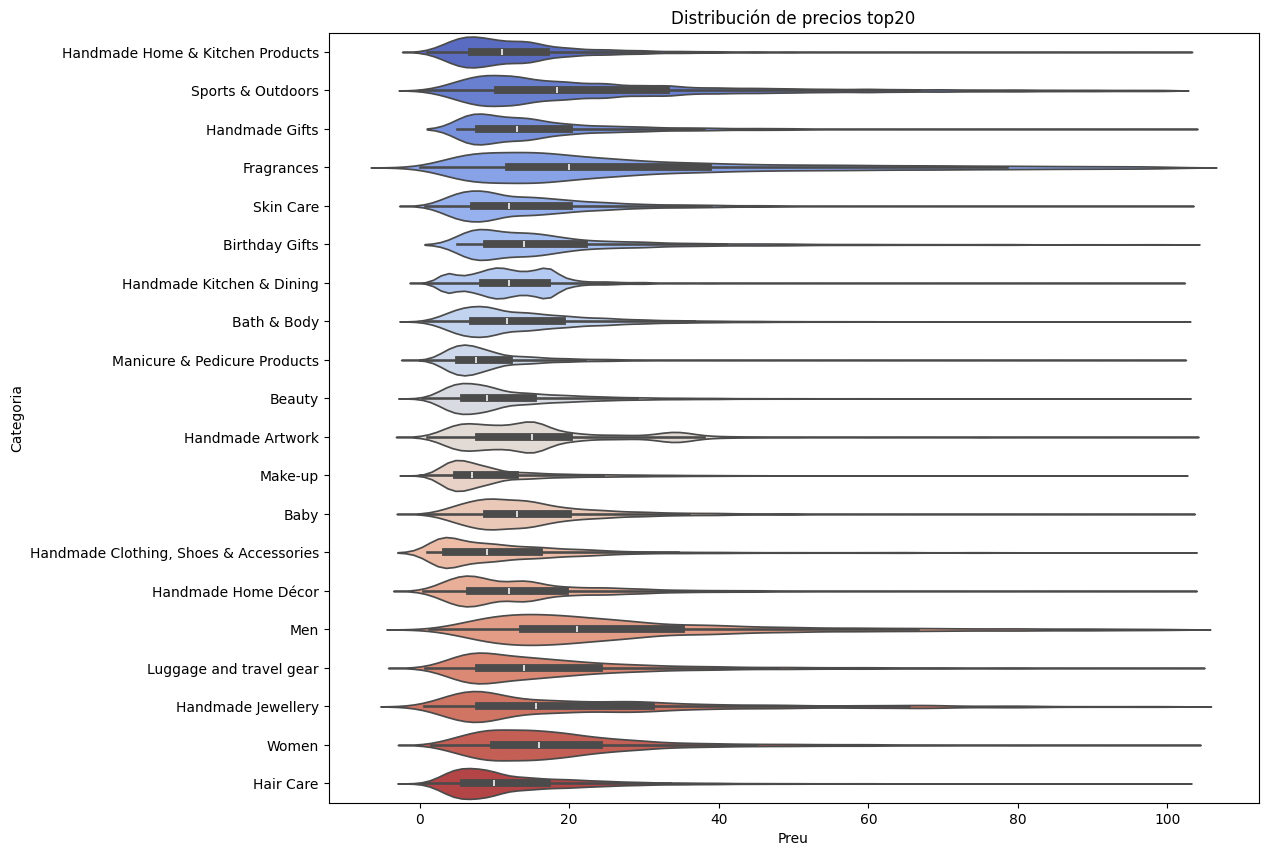

In [16]:
plt.figure(figsize=(12,10))

sns.violinplot(data=df_top20, x='price', y='category', palette="coolwarm")

plt.title('Distribución de precios top20')
plt.xlabel('Preu')
plt.ylabel('Categoria')
plt.show()

In [17]:
avg_prices = df_clean.groupby('category')['price'].mean().sort_values(ascending=False)
categoria_max_avg = avg_prices.idxmax()
valor_max_avg = avg_prices.max()
 
print(f"La categoria de precio medio mas alto: {categoria_max_avg} ({valor_max_avg:.2f}€)")

La categoria de precio medio mas alto: Motherboards (68.77€)


C:\Users\llam_\AppData\Local\Temp\ipykernel_111264\2771022839.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price_top_10, y=avg_price_top_10.index, palette="mako")


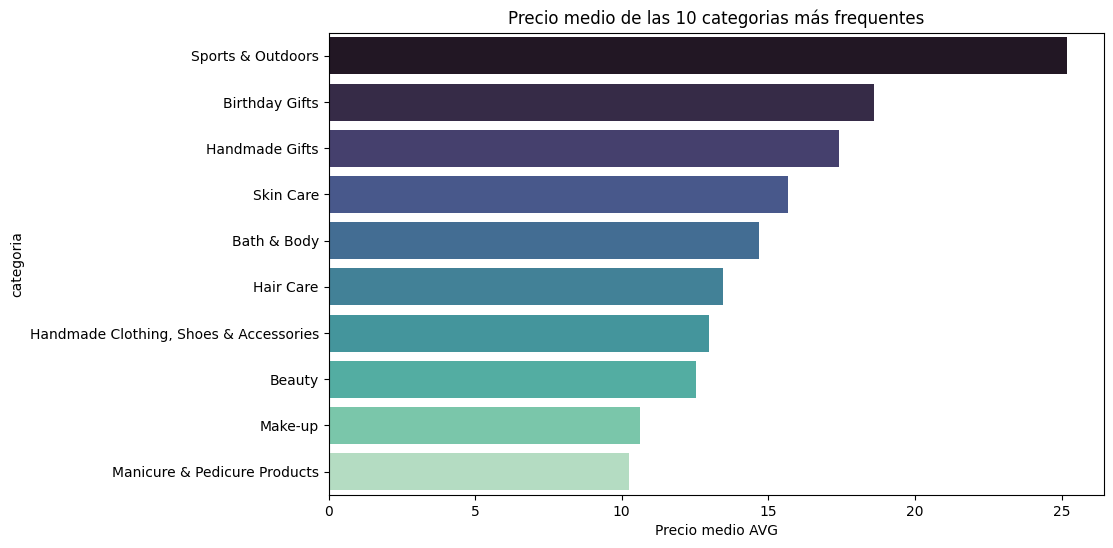

In [18]:
top_10_names = df_clean['category'].value_counts().head(10).index
avg_price_top_10 = avg_prices.loc[top_10_names].sort_values(ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(x=avg_price_top_10, y=avg_price_top_10.index, palette="mako")

plt.title("Precio medio de las 10 categorias más frequentes")
plt.xlabel("Precio medio AVG")
plt.ylabel("categoria")
plt.show()

C:\Users\llam_\AppData\Local\Temp\ipykernel_111264\4292627515.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ratings_top10, x='stars', y='category', palette='Set3')


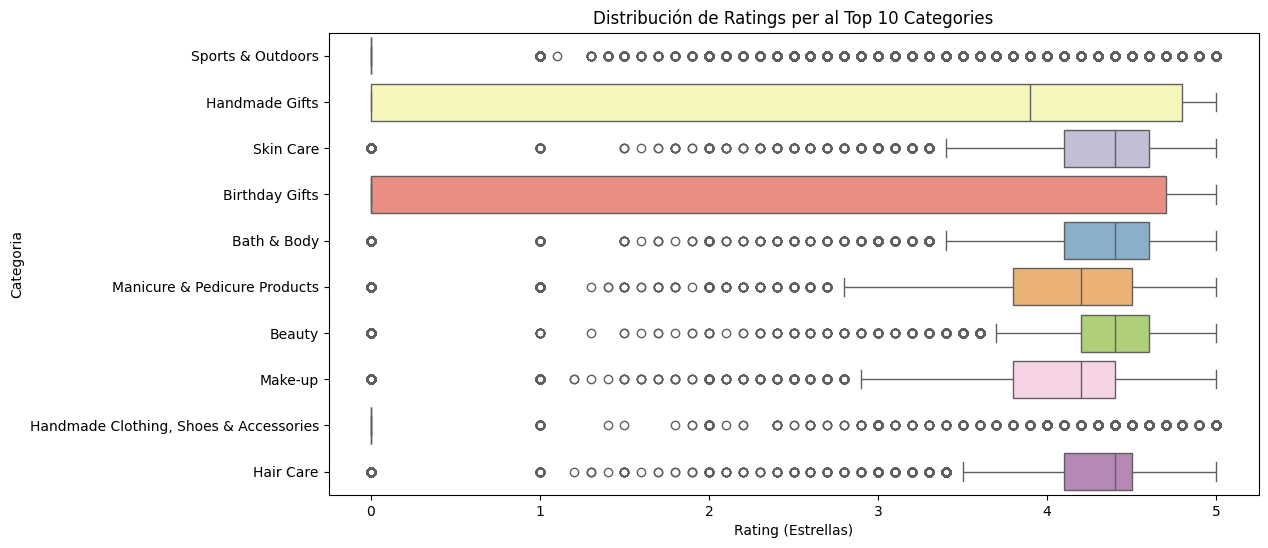

In [19]:
top_10_freqnames = df_clean['category'].value_counts().head(10).index

df_ratings_top10 = df_clean[df_clean['category'].isin(top_10_freqnames)]

plt.figure(figsize=(12, 6))

sns.boxplot(data=df_ratings_top10, x='stars', y='category', palette='Set3')

plt.title('Distribución de Ratings per al Top 10 Categories')
plt.xlabel('Rating (Estrellas)')
plt.ylabel('Categoria')
plt.show()

C:\Users\llam_\AppData\Local\Temp\ipykernel_111264\452275414.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ratings_top10, x='stars', y='category', palette='Set3', showfliers=False)


<Axes: xlabel='stars', ylabel='category'>

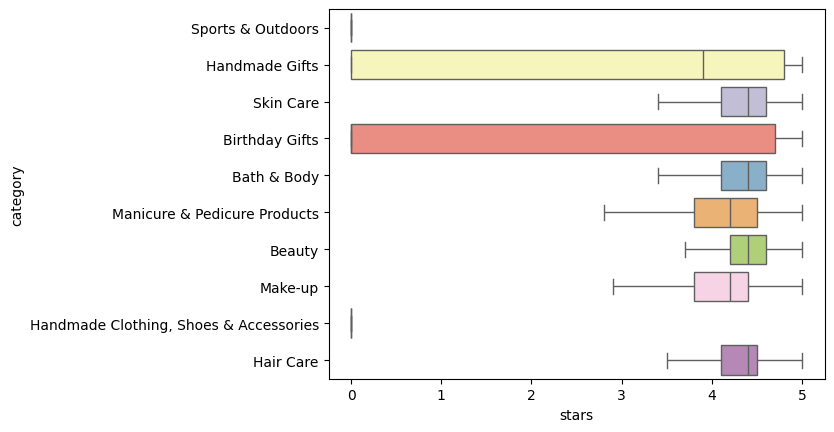

In [20]:
sns.boxplot(data=df_ratings_top10, x='stars', y='category', palette='Set3', showfliers=False)

In [21]:
pearson_corr = df_clean['price'].corr(df_clean['stars'], method='pearson')
spearman_corr = df_clean['price'].corr(df_clean['stars'], method='spearman')

print(f"Coeficiente de Pearson: {pearson_corr:.4f}")
print(f"Coeficiente de Spearman: {spearman_corr:.4f}")

Coeficiente de Pearson: -0.0777
Coeficiente de Spearman: -0.0668


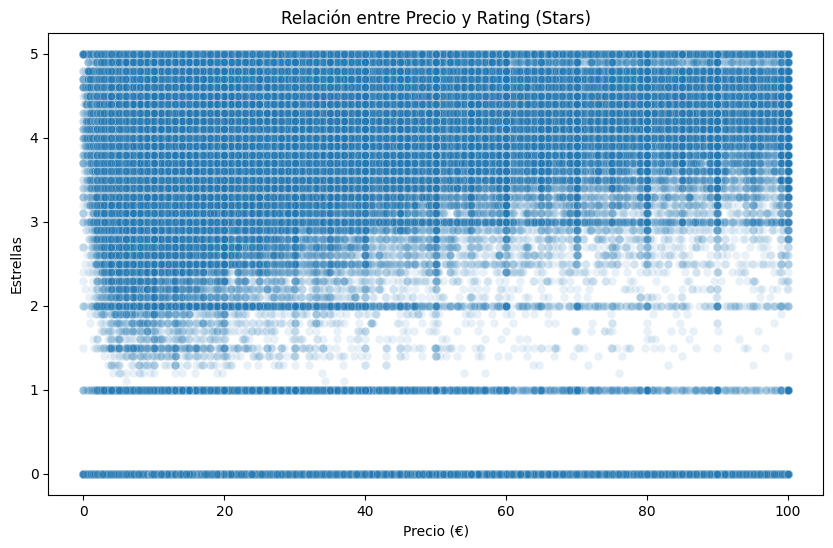

In [22]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_clean, x='price', y='stars', alpha=0.1)
plt.title('Relación entre Precio y Rating (Stars)')
plt.xlabel('Precio (€)')
plt.ylabel('Estrellas')
plt.show()

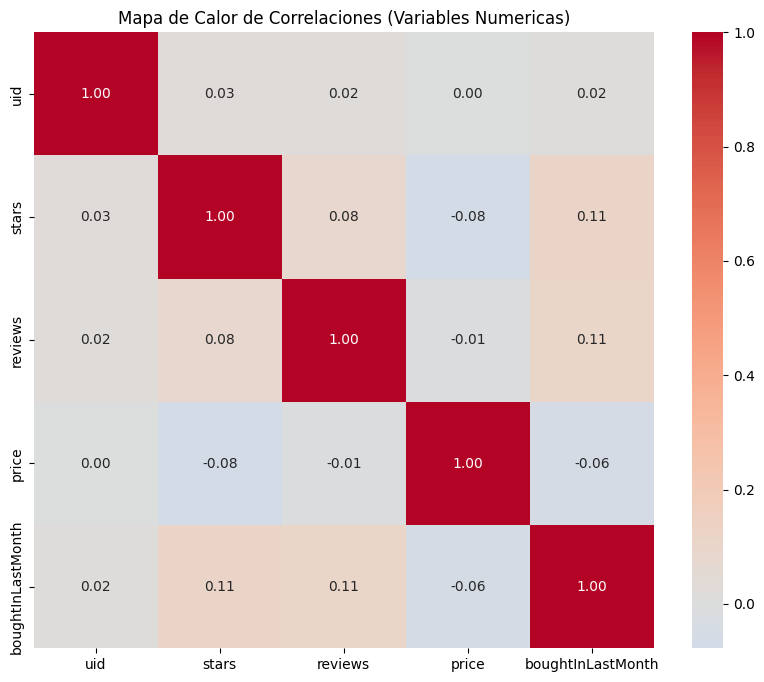

In [23]:
df_numeric = df_clean.select_dtypes(include=['number'])
corr_matrix = df_numeric.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", center=0)

plt.title('Mapa de Calor de Correlaciones (Variables Numericas)')
plt.show()

In [25]:
import scipy.stats as stats

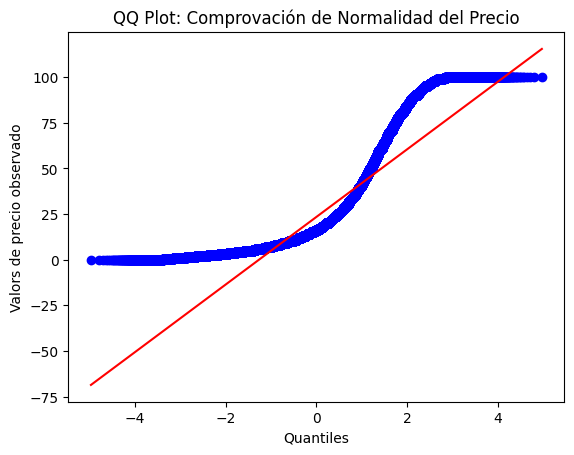

In [26]:
stats.probplot(df_clean['price'], dist="norm", plot=plt)

plt.title('QQ Plot: Comprovación de Normalidad del Precio')
plt.xlabel('Quantiles')
plt.ylabel('Valors de precio observado')
plt.show()